In [ ]:
### Sensitivity Analysis of the Number of Clusters

In [1]:
# install_github(repo="ntdyjack/fasthplus", ref = "main")
library(fasthplus)
library(SpatialExperiment)
library(here)
library("sessioninfo")
library(spatialLIBD)
library(dplyr)
library(stringr)
library(mclust)
library(pheatmap)
library(Seurat)
library(ggplot2)

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    

In [2]:
seuobj = readRDS(paste0("/data/Bin200.merge.seuobj.rds"))

In [ ]:
###bayes meta
meta= readRDS(paste0("/data/Bin200.all.bayes.clu.outcome.rds"))
meta[1:2,]

,cellid,Bayes2,Bayes7,Bayes12,Bayes16,Bayes20,Bayes24,Bayes13,Bayes14,Bayes15,Bayes17,Bayes18,Bayes19,Bayes21,Bayes22,Bayes23
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
T756_BIN200_27,T756_BIN200_27,1,1,10,14,15,22,11,12,14,14,15,16,17,21,22
T756_BIN200_28,T756_BIN200_28,1,1,1,1,4,21,1,1,1,1,1,4,1,1,1


In [ ]:
seuobj = AddMetaData(seuobj,meta)

In [ ]:
meta <- seuobj@meta.data

In [ ]:
# Extraction of All Bayesian Results
bayes_cols <- grep("^Bayes\\d+$", colnames(meta), value = TRUE)
bayes_cols
####Sort by q-size:
bayes_q <- as.numeric(str_extract(bayes_cols, "\\d+"))
bayes_cols <- bayes_cols[order(bayes_q)]
bayes_q <- sort(bayes_q)

[1] "Bayes16" "Bayes2"  "Bayes7"  "Bayes12" "Bayes20" "Bayes24" "Bayes13"
 [8] "Bayes14" "Bayes15" "Bayes17" "Bayes18" "Bayes19" "Bayes21" "Bayes22"
[15] "Bayes23"

In [11]:
### Define a function： purity and NMI
calc_purity <- function(pred, truth) {
  pred <- as.factor(pred)
  truth <- as.factor(truth)
  keep <- !is.na(pred) & !is.na(truth)
  tab <- table(pred[keep], truth[keep])
  sum(apply(tab, 1, max)) / sum(tab)
}

calc_nmi_manual <- function(x, y) {
  x <- as.factor(x)
  y <- as.factor(y)
  keep <- !is.na(x) & !is.na(y)
  x <- x[keep]
  y <- y[keep]
  
  tab <- table(x, y)
  n <- sum(tab)
  pxy <- tab / n
  px <- rowSums(pxy)
  py <- colSums(pxy)
  
  mi <- 0
  for (i in seq_len(nrow(pxy))) {
    for (j in seq_len(ncol(pxy))) {
      if (pxy[i, j] > 0) {
        mi <- mi + pxy[i, j] * log(pxy[i, j] / (px[i] * py[j]))
      }
    }
  }
  
  hx <- -sum(px[px > 0] * log(px[px > 0]))
  hy <- -sum(py[py > 0] * log(py[py > 0]))
  
  2 * mi / (hx + hy)
}


In [12]:
### Consistency between different *q* values and the artificial layer area#########
#
##########################################
sens_df <- data.frame()

for (col in bayes_cols) {
  pred <- as.factor(meta[[col]])
  truth <- as.factor(meta$area)
  keep <- !is.na(pred) & !is.na(truth)
  
  sens_df <- rbind(sens_df, data.frame(
    method = col,
    q = as.numeric(str_extract(col, "\\d+")),
    ARI = adjustedRandIndex(pred[keep], truth[keep]),
    Purity = calc_purity(pred, truth),
    NMI = calc_nmi_manual(pred, truth)
  ))
}

sens_df

,method,q,ARI,Purity,NMI
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Bayes2,2,0.06599368,0.3300854,0.2073223
11,Bayes7,7,0.55663408,0.7275918,0.6694017
12,Bayes12,12,0.44393737,0.7734472,0.6252440
13,Bayes13,13,0.40418341,0.8072039,0.6166697
14,Bayes14,14,0.39266719,0.8075733,0.6124881
15,Bayes15,15,0.38362058,0.8006003,0.6090623
16,Bayes16,16,0.36786759,0.7986608,0.6023231
17,Bayes17,17,0.36265631,0.7988455,0.5976575
18,Bayes18,18,0.34478805,0.7978296,0.5910894


In [13]:
##########  Stability across different q values
############  ARI of Adjacent q
q_stability <- data.frame()

for (i in 1:(length(bayes_cols) - 1)) {
  col1 <- bayes_cols[i]
  col2 <- bayes_cols[i + 1]
  
  cl1 <- as.factor(meta[[col1]])
  cl2 <- as.factor(meta[[col2]])
  keep <- !is.na(cl1) & !is.na(cl2)
  
  q_stability <- rbind(q_stability, data.frame(
    q1 = as.numeric(str_extract(col1, "\\d+")),
    q2 = as.numeric(str_extract(col2, "\\d+")),
    ARI_between_q = adjustedRandIndex(cl1[keep], cl2[keep])
  ))
}

q_stability

q1,q2,ARI_between_q
<dbl>,<dbl>,<dbl>
2,7,0.06119957
7,12,0.70688985
12,13,0.78190786
13,14,0.92560824
14,15,0.92086082
15,16,0.89703250
16,17,0.95765267
17,18,0.87652758
18,19,0.68458298


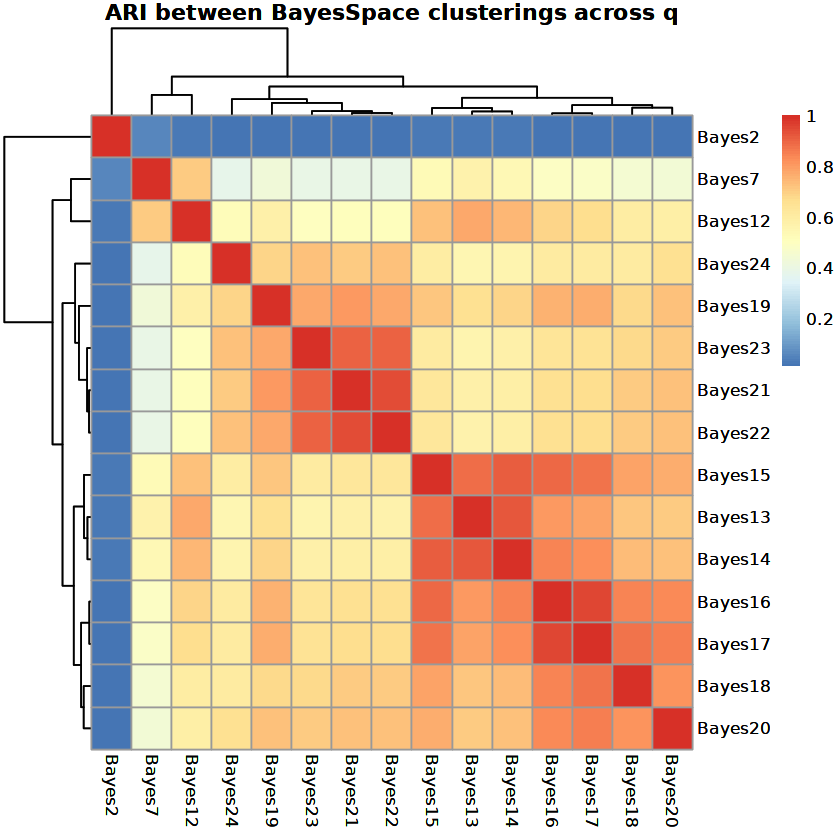

In [14]:
#### Heatmap of All Pairwise q-Value Comparisons
q_ari_mat <- matrix(NA, nrow = length(bayes_cols), ncol = length(bayes_cols),
                    dimnames = list(bayes_cols, bayes_cols))

for (i in seq_along(bayes_cols)) {
  for (j in seq_along(bayes_cols)) {
    cl1 <- as.factor(meta[[bayes_cols[i]]])
    cl2 <- as.factor(meta[[bayes_cols[j]]])
    keep <- !is.na(cl1) & !is.na(cl2)
    q_ari_mat[i, j] <- adjustedRandIndex(cl1[keep], cl2[keep])
  }
}
p = pheatmap(q_ari_mat, main = "ARI between BayesSpace clusterings across q")
p

In [49]:
#ggsave(plot=p,"/data/ARI.diff.cluster.heatmap.pdf")

Saving 6.67 x 6.67 in image


In [ ]:
#### Under-segmentation / Over-segmentation Analysis
#### How many clusters is each artificial layer divided into? # The higher the value, the more indicative it is of over-segmentation.

In [34]:
fragment_df <- data.frame()

for (col in bayes_cols) {
  tmp <- meta %>%
    filter(!is.na(.data[[col]]), !is.na(area)) %>%
    group_by(area) %>%
    summarise(
      n_clusters_in_area = n_distinct(.data[[col]]),
      .groups = "drop"
    ) %>%
    mutate(
      q = as.numeric(str_extract(col, "\\d+")),
      method = col
    )
  
  fragment_df <- rbind(fragment_df, tmp)
}

fragment_summary <- fragment_df %>%
  group_by(q, method) %>%
  summarise(
    mean_clusters_per_area = mean(n_clusters_in_area),
    median_clusters_per_area = median(n_clusters_in_area),
    .groups = "drop"
  )
fragment_summary

q,method,mean_clusters_per_area,median_clusters_per_area
<dbl>,<chr>,<dbl>,<int>
2,Bayes2,1.714286,2
7,Bayes7,5.285714,6
12,Bayes12,8.142857,8
13,Bayes13,8.571429,8
14,Bayes14,9.142857,9
15,Bayes15,8.428571,9
16,Bayes16,8.857143,9
17,Bayes17,9.285714,10
18,Bayes18,9.857143,10


In [36]:
### The number of artificial layers blended into each Bayes cluster # A higher value indicates a greater tendency toward under-segmentation.
### High `mean_clusters_per_area`: A single layer is fragmented into many pieces, leaning toward over-segmentation.
### High `mean_area_per_cluster`: A single cluster encompasses multiple layers, leaning toward under-segmentation.

In [37]:
mix_df <- data.frame()
for (col in bayes_cols) {
  tmp <- meta %>%
    filter(!is.na(.data[[col]]), !is.na(area)) %>%
    group_by(cluster = .data[[col]]) %>%
    summarise(
      n_area_in_cluster = n_distinct(area),
      .groups = "drop"
    ) %>%
    mutate(
      q = as.numeric(str_extract(col, "\\d+")),
      method = col
    )
  
  mix_df <- rbind(mix_df, tmp)
}

mix_summary <- mix_df %>%
  group_by(q, method) %>%
  summarise(
    mean_area_per_cluster = mean(n_area_in_cluster),
    median_area_per_cluster = median(n_area_in_cluster),
    .groups = "drop"
  )
mix_summary

q,method,mean_area_per_cluster,median_area_per_cluster
<dbl>,<chr>,<dbl>,<dbl>
2,Bayes2,6.000000,6.0
7,Bayes7,5.285714,6.0
12,Bayes12,4.750000,5.5
13,Bayes13,4.615385,5.0
14,Bayes14,4.571429,4.0
15,Bayes15,3.933333,3.0
16,Bayes16,3.875000,3.0
17,Bayes17,3.823529,3.0
18,Bayes18,3.833333,3.0


In [ ]:
# plot 
# Consistency of Different q Values with the Artificial Layer

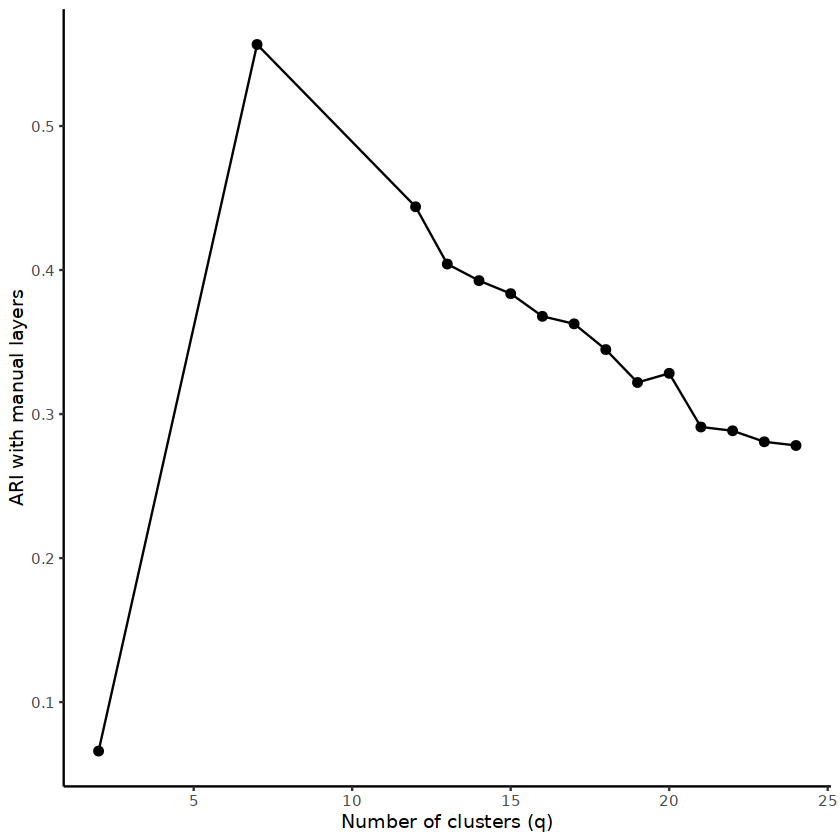

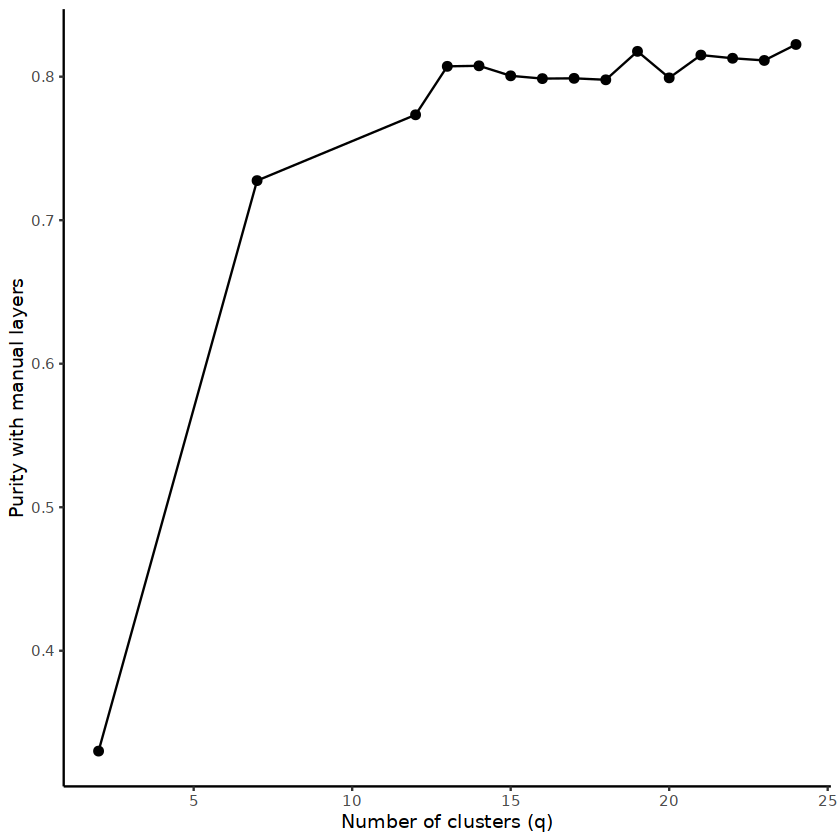

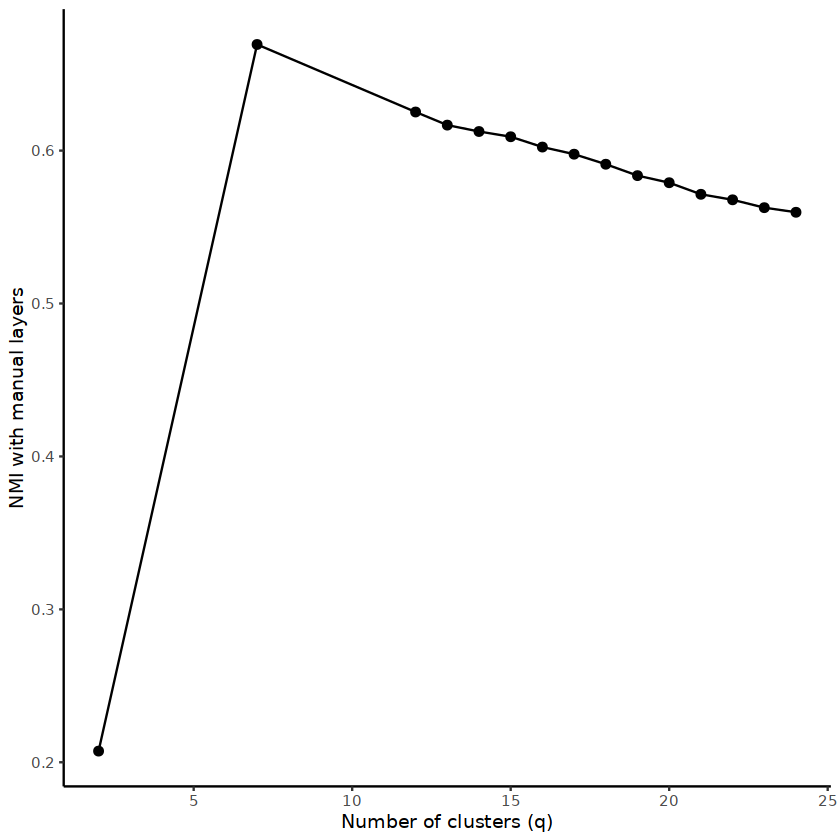

In [50]:
p1 <- ggplot(sens_df, aes(x = q, y = ARI)) +  ###和人工层次的一致性。
  geom_line() +
  geom_point(size = 2) +
  theme_classic() +
  labs(x = "Number of clusters (q)", y = "ARI with manual layers")

p2 <- ggplot(sens_df, aes(x = q, y = Purity)) +     #### 每个 cluster 的纯度。
  geom_line() +
  geom_point(size = 2) +
  theme_classic() +
  labs(x = "Number of clusters (q)", y = "Purity with manual layers")

p3 <- ggplot(sens_df, aes(x = q, y = NMI)) +    ####和 ARI 类似，也是看和人工层的一致性，但比 ARI 稍微更稳一些。
  geom_line() +
  geom_point(size = 2) +
  theme_classic() +
  labs(x = "Number of clusters (q)", y = "NMI with manual layers")

print(p1)
print(p2)
print(p3)

In [51]:
p = p1+p2+p3

In [53]:
ggsave(plot=p,"/data/ARI.purity.NMI.line.pdf",width=13,height=6)

In [ ]:
####  Adjacent q-Stability (Higher values indicate smaller changes in results between two adjacent q values.)

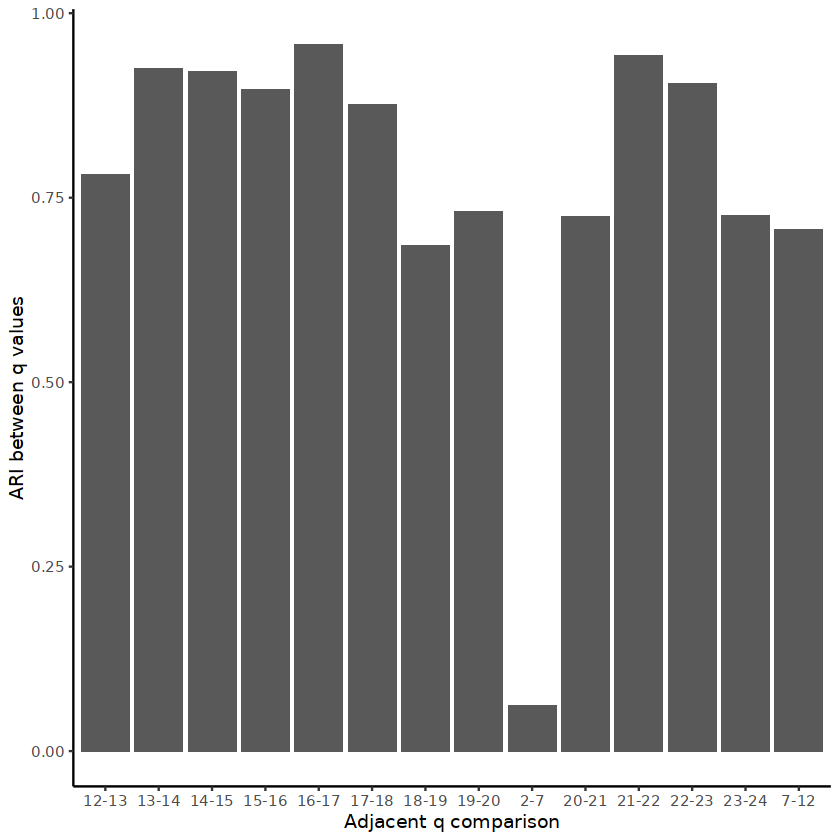

In [54]:
p4 <- ggplot(q_stability, aes(x = paste0(q1, "-", q2), y = ARI_between_q)) +
  geom_col() +
  theme_classic() +
  labs(x = "Adjacent q comparison", y = "ARI between q values")

print(p4)

In [55]:
ggsave(plot=p4,"/data/q_stability.barplot.pdf")

Saving 6.67 x 6.67 in image


In [ ]:
# Under-segmentation/Over-segmentation Trends

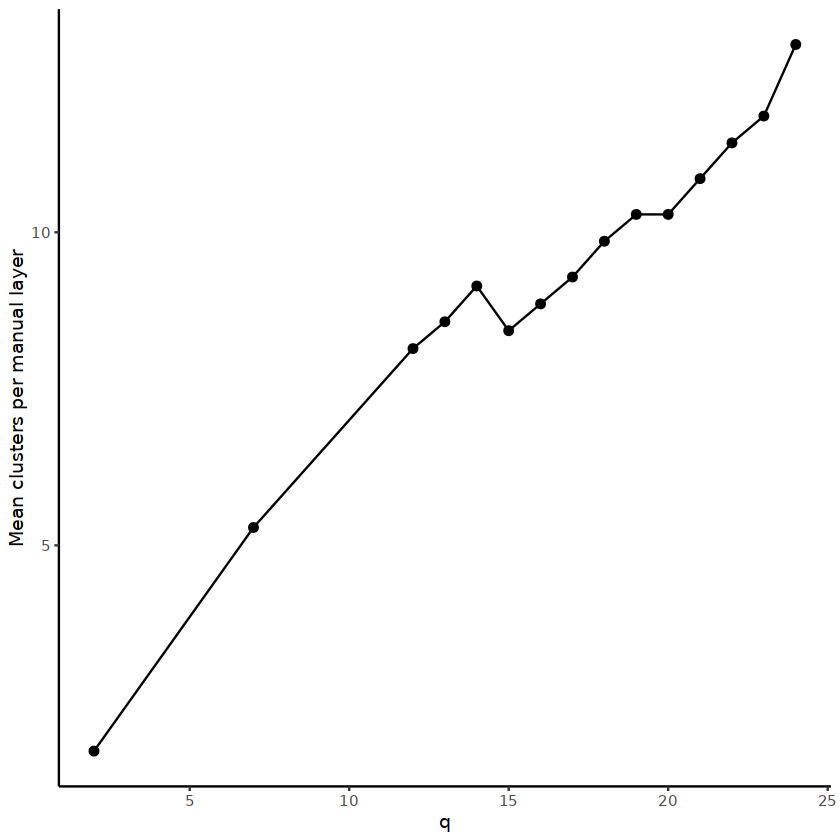

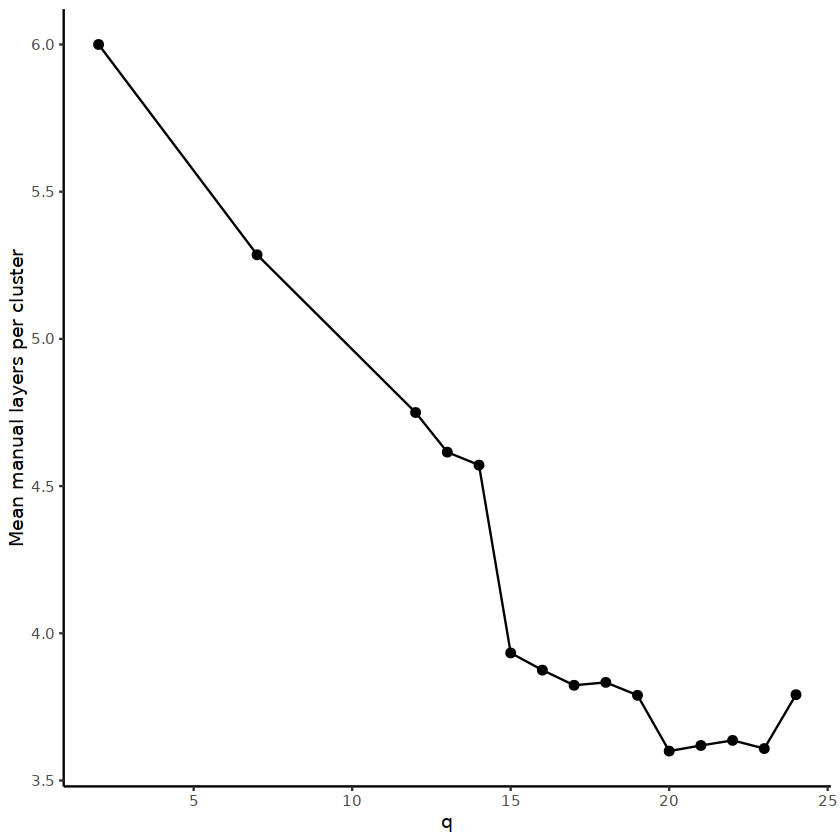

In [56]:
p5 <- ggplot(fragment_summary, aes(x = q, y = mean_clusters_per_area)) +   #########这是过分割指标。 越高，说明一个人工层被拆成更多 cluster, 越高越偏向过分割  随着 q 增大，这个值几乎单调上升, q >= 20 时更明显
  geom_line() +
  geom_point(size = 2) +
  theme_classic() +
  labs(x = "q", y = "Mean clusters per manual layer")

p6 <- ggplot(mix_summary, aes(x = q, y = mean_area_per_cluster)) +   #这是欠分割指标。越高，说明一个 cluster 混了更多人工层,越高越偏向欠分割
  geom_line() +
  geom_point(size = 2) +
  theme_classic() +
  labs(x = "q", y = "Mean manual layers per cluster")
print(p5)
print(p6)

In [58]:
p=p5+p6

In [60]:
ggsave(plot=p,"/data/cluster-layer.line.pdf",width=12)

Saving 12 x 6.67 in image
